In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns


Cleaned Data Importing

In [2]:
df=pd.read_csv("E:\\Online_Food_Delivery_Analysis\\EDA\\food_delivery_cleaned.csv")

In [3]:
df.head()

,order_id,customer_id,customer_gender,city,area,restaurant_id,restaurant_name,cuisine_type,order_date,delivery_time_min,...,final_amount,payment_mode,order_status,cancellation_reason,delivery_partner_id,delivery_rating,restaurant_rating,order_day,peak_hour,profit_margin
0,ORD000002,CUST6515,female,chennai,north,RES689,restaurant_419,chinese,2024-08-12,20.0,...,4849.0,cod,delivered,not_cancelled,DP369,5.0,4.7,weekday,True,0.48
1,ORD000003,CUST1765,male,delhi,NaN,RES723,restaurant_244,arabian,2024-12-08,207.0,...,737.0,wallet,delivered,not_cancelled,DP580,4.0,4.9,weekend,True,0.08
2,ORD000005,CUST4389,female,chennai,south,RES419,restaurant_262,chinese,2024-02-04,51.0,...,352.0,card,delivered,not_cancelled,DP728,2.0,4.4,weekend,False,0.12
3,ORD000008,CUST5865,male,unknown,north,RES696,restaurant_41,chinese,2024-05-26,NaN,...,3486.0,upi,delivered,not_cancelled,DP316,5.0,3.8,weekend,True,0.18
4,ORD000009,CUST4356,other,delhi,central,RES780,restaurant_155,italian,2024-09-07,NaN,...,425.0,NaN,delivered,not_cancelled,DP531,2.0,3.7,weekend,True,0.08


In [4]:
df.shape

(54194, 23)

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
delivery_time_min,35984.0,127.917769,90.899554,20.0,45.00,121.00,210.00,300.0
distance_km,36153.0,16.478756,12.223421,1.0,5.55,9.99,27.47,40.0
order_value,54194.0,2101.680924,1548.230763,150.0,691.00,2020.00,3504.00,5000.0
discount_applied,54194.0,90.896594,106.195468,0.0,20.00,50.00,100.00,300.0
final_amount,54194.0,2010.784330,1547.794351,0.0,598.00,1787.00,3416.00,5000.0
delivery_rating,45184.0,3.002080,1.413461,1.0,2.00,3.00,4.00,5.0
restaurant_rating,54194.0,4.203550,0.653467,3.0,3.60,4.30,4.90,5.0
profit_margin,54194.0,0.150237,0.202281,-0.2,-0.02,0.15,0.32,0.5


In [7]:
df['area']=df['area'].fillna("unknown")

In [8]:
df['cuisine_type']=df['cuisine_type'].fillna("unknown")

In [9]:
df['payment_mode']=df['payment_mode'].fillna("unknown")

In [10]:
df.isnull().sum()

order_id                   0
customer_id                0
customer_gender            0
city                       0
area                       0
restaurant_id              0
restaurant_name            0
cuisine_type               0
order_date                 0
delivery_time_min      18210
distance_km            18041
order_value                0
discount_applied           0
final_amount               0
payment_mode               0
order_status               0
cancellation_reason        0
delivery_partner_id        0
delivery_rating         9010
restaurant_rating          0
order_day                  0
peak_hour                  0
profit_margin              0
dtype: int64

In [11]:
df.columns

Index(['order_id', 'customer_id', 'customer_gender', 'city', 'area',
       'restaurant_id', 'restaurant_name', 'cuisine_type', 'order_date',
       'delivery_time_min', 'distance_km', 'order_value', 'discount_applied',
       'final_amount', 'payment_mode', 'order_status', 'cancellation_reason',
       'delivery_partner_id', 'delivery_rating', 'restaurant_rating',
       'order_day', 'peak_hour', 'profit_margin'],
      dtype='str')

Univarient Analysis

## Order Status

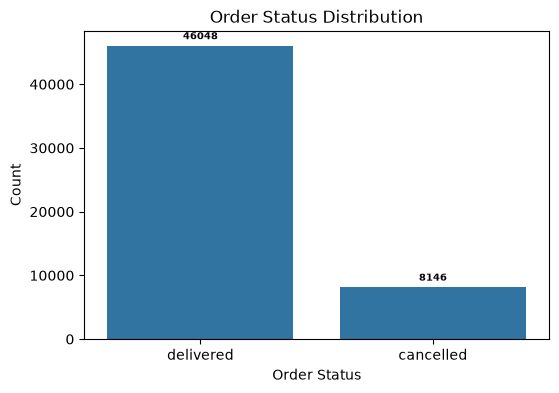

In [19]:
plt.figure(figsize=(6,4))
ax=sns.countplot(data=df,x="order_status")

for container in ax.containers:
    ax.bar_label(container, fontsize=7, fontweight="bold", padding=3)
plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Count")
plt.show()

In [22]:
df.columns

Index(['order_id', 'customer_id', 'customer_gender', 'city', 'area',
       'restaurant_id', 'restaurant_name', 'cuisine_type', 'order_date',
       'delivery_time_min', 'distance_km', 'order_value', 'discount_applied',
       'final_amount', 'payment_mode', 'order_status', 'cancellation_reason',
       'delivery_partner_id', 'delivery_rating', 'restaurant_rating',
       'order_day', 'peak_hour', 'profit_margin'],
      dtype='str')

In [26]:
cat_col=['customer_gender','city','area','cuisine_type','payment_mode','order_status','cancellation_reason','order_day']

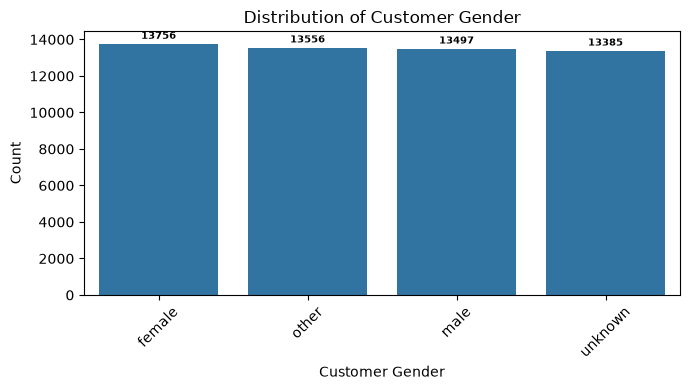

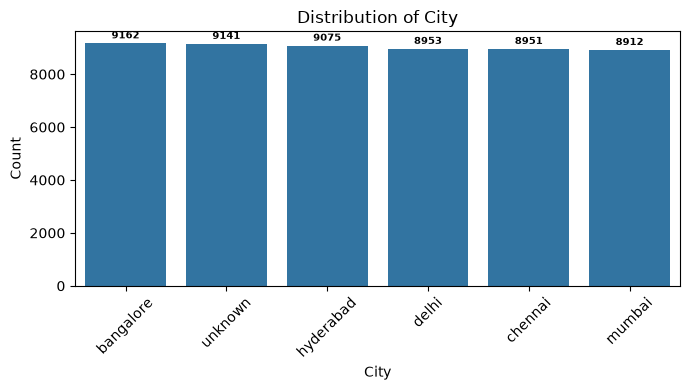

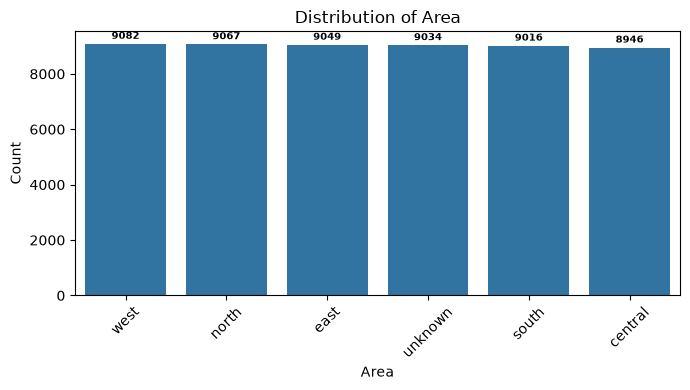

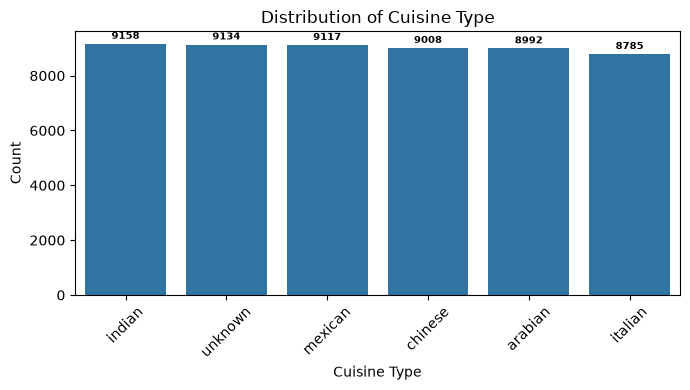

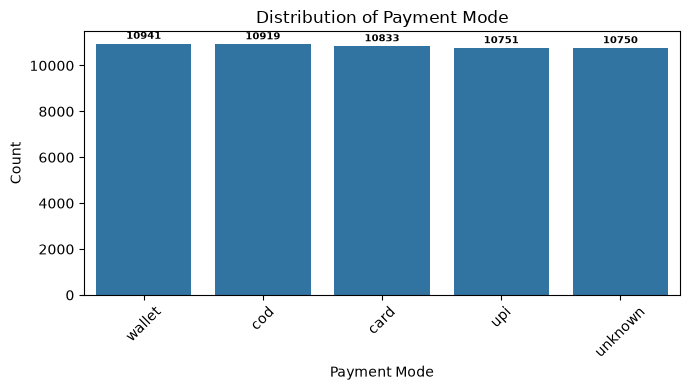

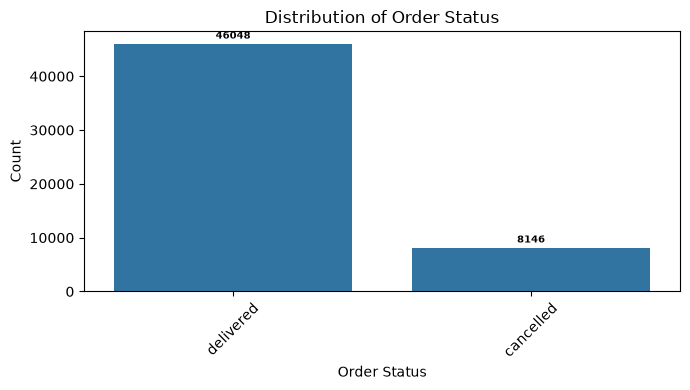

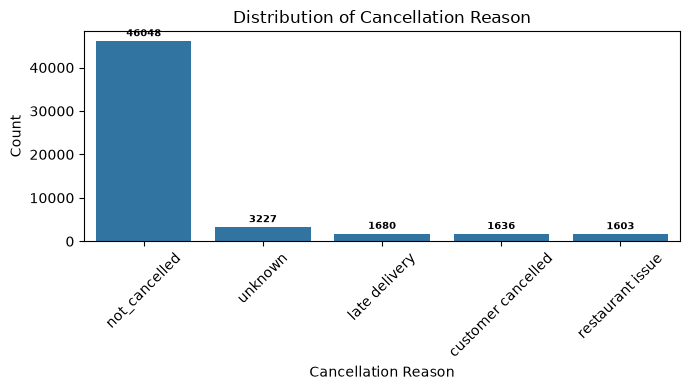

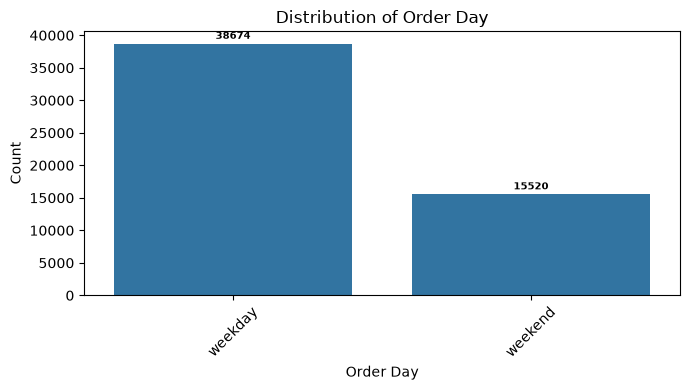

In [28]:
for col in cat_col:
    plt.figure(figsize=(7,4))
    ax=sns.countplot(data=df,x=col,order=df[col].value_counts().index)
    for container in ax.containers:
        ax.bar_label(container, fontsize=7, fontweight='bold', padding=2)

    plt.title(f"Distribution of {col.replace('_', ' ').title()}")
    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Count")

    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

<Axes: xlabel='peak_hour', ylabel='count'>

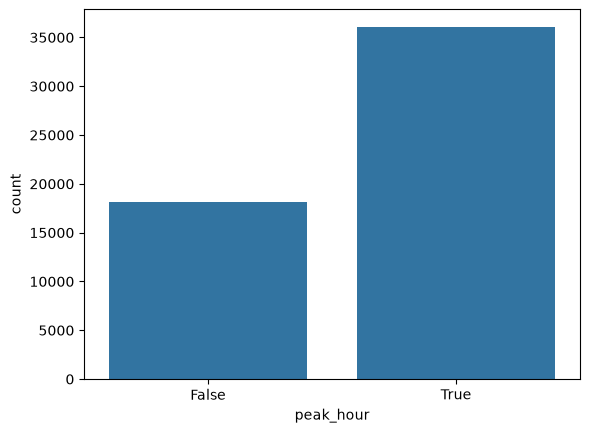

In [46]:
sns.countplot(data=df,x="peak_hour")

Bivarient Analysis

In [40]:
## Orders by city
city_orders=(df.groupby("city")["order_id"].count().sort_values(ascending=False).reset_index(name="total_orders"))
city_orders

,city,total_orders
0,bangalore,9162
1,unknown,9141
2,hyderabad,9075
3,delhi,8953
4,chennai,8951
5,mumbai,8912


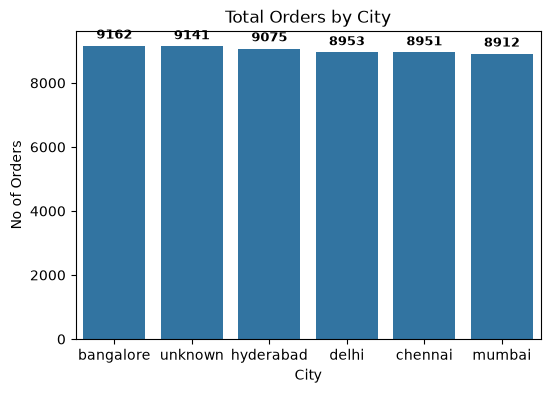

In [38]:
plt.figure(figsize=(6,4))
ax=sns.barplot(data=city_orders,x="city",y="total_orders")

for container in ax.containers:
        ax.bar_label(container, fontsize=9, fontweight="bold", padding=3)
plt.title("Total Orders by City")
plt.xlabel("City")
plt.ylabel("No of Orders")
plt.tight_layout
plt.show()

In [44]:
## Average Order value by gender

avg_order_value=(df.groupby('customer_gender')['order_value'].mean().sort_values(ascending=False).reset_index(name="average_order_value"))
avg_order_value

,customer_gender,average_order_value
0,other,2111.979197
1,female,2109.239605
2,unknown,2097.059320
3,male,2088.217159


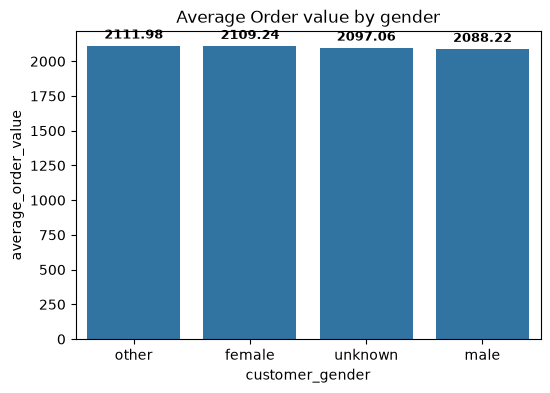

In [45]:
plt.figure(figsize=(6,4))
ax=sns.barplot(data=avg_order_value,x="customer_gender",y="average_order_value")

for container in ax.containers:
        ax.bar_label(container, fontsize=9, fontweight="bold", padding=3)
plt.title("Average Order value by gender")
plt.xlabel("customer_gender")
plt.ylabel("average_order_value")
plt.tight_layout
plt.show()

In [47]:
df.columns

Index(['order_id', 'customer_id', 'customer_gender', 'city', 'area',
       'restaurant_id', 'restaurant_name', 'cuisine_type', 'order_date',
       'delivery_time_min', 'distance_km', 'order_value', 'discount_applied',
       'final_amount', 'payment_mode', 'order_status', 'cancellation_reason',
       'delivery_partner_id', 'delivery_rating', 'restaurant_rating',
       'order_day', 'peak_hour', 'profit_margin'],
      dtype='str')

In [51]:
df['delivery_time_min'].describe()

count    35984.000000
mean       127.917769
std         90.899554
min         20.000000
25%         45.000000
50%        121.000000
75%        210.000000
max        300.000000
Name: delivery_time_min, dtype: float64

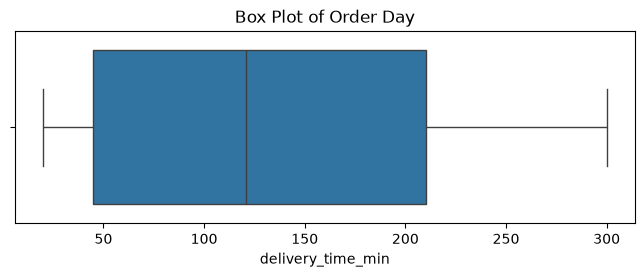

In [57]:
plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df['delivery_time_min'])
plt.title(f"Box Plot of {col.replace('_', ' ').title()}")
plt.show()

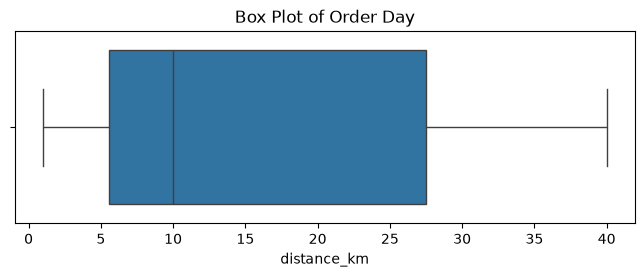

In [58]:
plt.figure(figsize=(8, 2.5))
sns.boxplot(x=df['distance_km'])
plt.title(f"Box Plot of {col.replace('_', ' ').title()}")
plt.show()

In [62]:
df.groupby('distance_km')['delivery_time_min'].mean()

distance_km
1.00     130.875000
1.01     112.062500
1.02     102.692308
1.03     116.266667
1.04     160.538462
            ...    
39.96     95.222222
39.97    104.400000
39.98    177.750000
39.99    131.800000
40.00    194.000000
Name: delivery_time_min, Length: 3401, dtype: float64

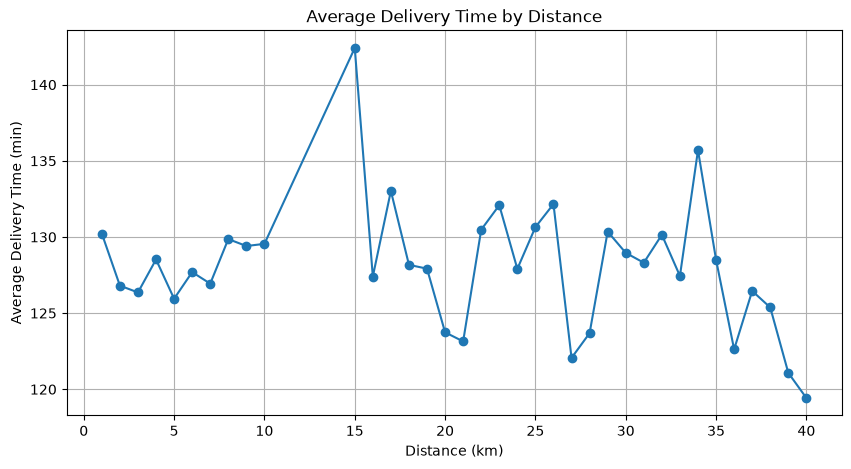

In [67]:
df['distance_round'] = df['distance_km'].round()
distance_analysis = (df.groupby('distance_round')['delivery_time_min'].mean().reset_index())

plt.figure(figsize=(10,5))
plt.plot(distance_analysis['distance_round'],distance_analysis['delivery_time_min'],marker='o')

plt.title('Average Delivery Time by Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Average Delivery Time (min)')
plt.grid(True)
plt.show()

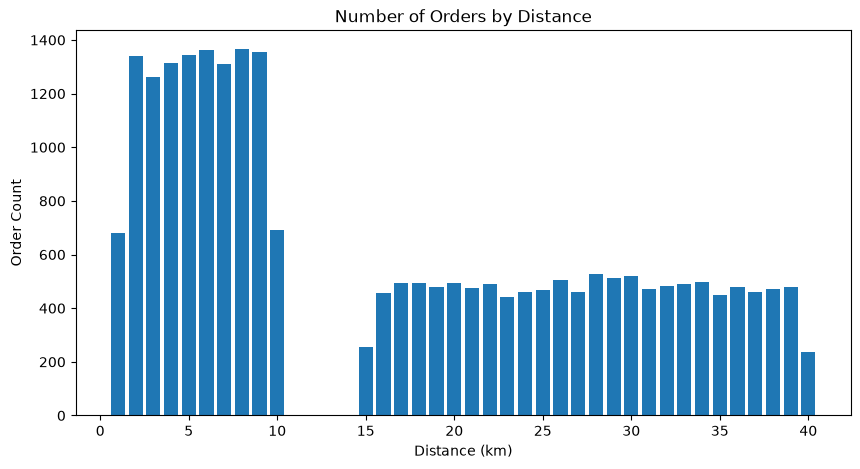

In [68]:
distance_count = (df.groupby('distance_round')['delivery_time_min'].count().reset_index(name='orders'))

plt.figure(figsize=(10,5))
plt.bar(distance_count['distance_round'], distance_count['orders'])
plt.title('Number of Orders by Distance')
plt.xlabel('Distance (km)')
plt.ylabel('Order Count')
plt.show()

In [69]:
corr = df['distance_km'].corr(df['delivery_time_min'])
print(f"Correlation: {corr:.2f}")

Correlation: -0.00


Distance vs Delivery Time: The correlation coefficient between delivery distance and delivery time is -0.00, indicating no significant linear relationship. This suggests that delivery duration is influenced more by other operational factors than by distance in this dataset

Distribution of Order values

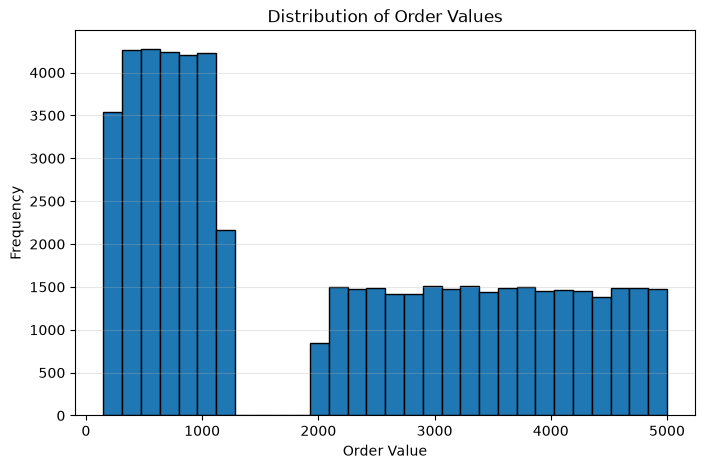

In [70]:
plt.figure(figsize=(8,5))

plt.hist(df['order_value'], bins=30, edgecolor='black')

plt.title('Distribution of Order Values')
plt.xlabel('Order Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()

C:\Users\navin\AppData\Local\Temp\ipykernel_24356\2856450697.py:3: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(df['order_value'], vert=False)


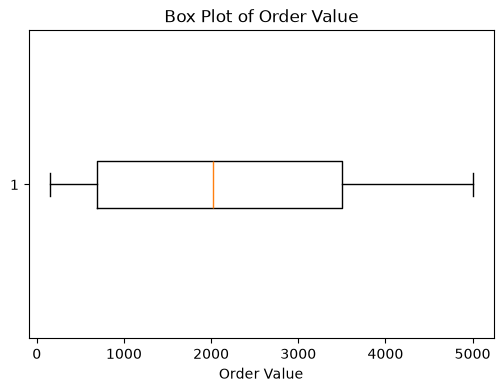

In [72]:
plt.figure(figsize=(6,4))

plt.boxplot(df['order_value'], vert=False)

plt.title('Box Plot of Order Value')
plt.xlabel('Order Value')

plt.show()

Distribution of Delicery time

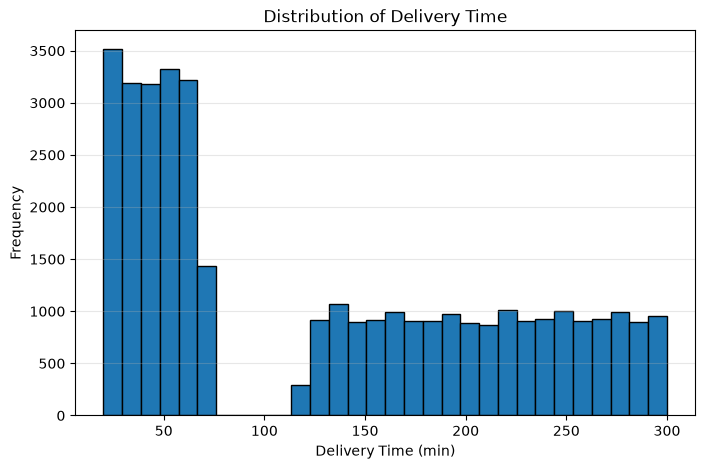

In [71]:
plt.figure(figsize=(8,5))

plt.hist(df['delivery_time_min'], bins=30, edgecolor='black')

plt.title('Distribution of Delivery Time')
plt.xlabel('Delivery Time (min)')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.3)

plt.show()